# NLP Foundations: From Text to Word Embeddings
### Hands-On Session

---

> **Who is this for?**  
> You have basic Python knowledge (variables, loops, functions) but have **never worked with NLP** before. We will build everything from absolute scratch, explaining every library and every concept step by step.

---

## What We Will Cover Today

| # | Topic |
|---|-------|
| 1 | What is NLP? Why does it matter?
| 2 | Our Tools: Installing & Importing Libraries
| 3 | Working with Text in Python
| 4 | Regular Expressions (Regex) for Text Cleaning
| 5 | Tokenisation — Splitting Text into Word
| 6 | Stopwords, Stemming & Lemmatisation
| 7 | Turning Words into Numbers — BoW & TF-IDF
| 8 | Word Embeddings — Words as Vectors

---

**By the end of this session you will be able to:**
- Clean and prepare raw text for machine learning
- Understand how computers "read" text
- Build Bag-of-Words and TF-IDF representations
- Load and use pre-trained Word2Vec embeddings
- Understand *why* word embeddings are powerful

---
# Section 1 — What Is NLP and Why Does It Matter?

**Natural Language Processing (NLP)** is the branch of AI that teaches computers to understand, process, and generate **human language** — text or speech.

### Real-world NLP is everywhere:
- 📧 **Gmail's Smart Reply** — suggests short replies to emails
- 🔍 **Google Search** — understands what you *mean*, not just what you *type*
- 🤖 **ChatGPT** — generates human-like text
- 📱 **Siri / Alexa** — converts speech to commands
- 🏥 **Hospital systems** — extract diagnoses from doctor's notes

### Why is NLP hard for computers?

Computers natively understand **numbers** — not words. The sentence:

> *"The bank can guarantee deposits will eventually cover future tuition costs."*

Is ambiguous — does *bank* mean a **financial institution** or a **river bank**?  
Humans resolve this instantly using context. Computers need to be taught how.

### The Core NLP Challenge:
```
Raw Text  →  Clean Text  →  Numbers  →  Machine Learning Model  →  Prediction
```
Today we will build every step of this pipeline.

---
# Section 2 — Our Tools: Python Libraries for NLP

Before we write a single line of NLP code, we need to understand **what libraries we are using and why**.

Think of a library as a **toolbox** — someone else already built the tools, we just use them.

| Library | What it does | Why we use it |
|---------|-------------|---------------|
| `re` | **Regular Expressions** — pattern matching in text | Built into Python, no install needed |
| `nltk` | **Natural Language Toolkit** — tokenising, stopwords, stemming | The classic NLP teaching library |
| `spacy` | **Industrial NLP** — fast, accurate linguistic analysis | Production-ready NLP |
| `sklearn` | **Scikit-Learn** — machine learning including BoW, TF-IDF | The go-to ML library for Python |
| `gensim` | **Word embeddings** — Word2Vec, Doc2Vec | Best library for word vectors |
| `numpy` | **Numerical arrays** — stores and manipulates numbers | The foundation of all scientific Python |
| `pandas` | **DataFrames** — tabular data handling | For loading and exploring text datasets |

---
### Mental Model: The NLP Stack
```
┌─────────────────────────────────────┐
│  Your NLP Application (classifier)  │
├─────────────────────────────────────┤
│  sklearn / gensim  (ML + Embeddings)│
├─────────────────────────────────────┤
│  nltk / spacy  (Text Processing)    │
├─────────────────────────────────────┤
│  re  (Pattern Matching)             │
├─────────────────────────────────────┤
│  Python strings  (Raw Text)         │
└─────────────────────────────────────┘
```

In [1]:
# ── STEP 1: Install libraries (run this once) ──────────────────────────────
# The exclamation mark tells Jupyter to run a terminal command
# If these are already installed, pip will just say 'already satisfied'

!pip install nltk spacy scikit-learn gensim numpy pandas --quiet

# Download the small English spaCy model
!python -m spacy download en_core_web_sm --quiet

print("✅ All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 32.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


In [2]:
# ── STEP 2: Import everything we need ─────────────────────────────────────
# 'import' makes a library available in our code
# 'as' gives it a shorter nickname so we don't have to type the full name

import re           # Regular expressions (pattern matching)
import nltk         # Natural Language Toolkit
import spacy        # Industrial NLP
import numpy as np  # Numerical arrays (np is the standard nickname)
import pandas as pd # DataFrames (pd is the standard nickname)

# From sklearn, we import specific tools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Download NLTK data packages (tokenizers, stopwords etc.)
# These are small data files that NLTK needs to work
nltk.download('punkt',        quiet=True)  # Sentence/word tokenizer
nltk.download('punkt_tab',    quiet=True)  # Updated tokenizer data
nltk.download('stopwords',    quiet=True)  # List of common words to ignore
nltk.download('wordnet',      quiet=True)  # Dictionary for lemmatisation
nltk.download('averaged_perceptron_tagger', quiet=True)  # POS tagger

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

print("✅ All imports successful!")
print(f"   NLTK version  : {nltk.__version__}")
print(f"   spaCy version : {spacy.__version__}")
print(f"   NumPy version : {np.__version__}")
print(f"   pandas version: {pd.__version__}")

✅ All imports successful!
   NLTK version  : 3.9.1
   spaCy version : 3.8.11
   NumPy version : 2.0.2
   pandas version: 2.2.2


---
# Section 3 — Working with Text in Python

Before we use any NLP library, let's remember that text in Python is just a **string** — a sequence of characters.  
Python has many built-in string methods that are already useful for text processing.

> **Goal of this section:** Understand what raw text looks like, and do basic cleaning with plain Python before we bring in specialised tools.

In [3]:
# ── A sample sentence we will work with throughout ────────────────────────
# This is a realistic piece of text — messy, with punctuation, numbers, URLs

raw_text = """
Breaking News (2024-01-15): Apple Inc. has JUST announced its new iPhone 16!!
Visit https://www.apple.com/iphone for more details.
The device costs $999 and ships on Jan 31st.
Customers say: 'It's the best phone EVER made!'
Pre-orders are available NOW — don't miss out!!!
"""

print("Our raw text:")
print(raw_text)
print(f"\nNumber of characters : {len(raw_text)}")
print(f"Number of lines      : {raw_text.count(chr(10))}")

Our raw text:

Breaking News (2024-01-15): Apple Inc. has JUST announced its new iPhone 16!!
Visit https://www.apple.com/iphone for more details. 
The device costs $999 and ships on Jan 31st. 
Customers say: 'It's the best phone EVER made!' 
Pre-orders are available NOW — don't miss out!!!


Number of characters : 277
Number of lines      : 6


In [4]:
# ── Basic Python string operations ────────────────────────────────────────
# These are built-in — no library needed

# 1. Convert to lowercase (important! 'Apple' and 'apple' should be the same word)
lowered = raw_text.lower()
print("1. Lowercase:")
print(lowered[:100], "...")
print()

# 2. Strip leading/trailing whitespace
stripped = raw_text.strip()
print("2. After strip(), no leading/trailing whitespace")
print()

# 3. Split into words (naive — just splits on spaces)
words_naive = raw_text.lower().split()
print(f"3. Naive word split ({len(words_naive)} words):")
print(words_naive[:15])
print()
print("⚠️  Notice the problem: 'iphone' has '!!' attached, '16!!' is not a word")
print("   We need something smarter — that's what tokenisers are for.")

1. Lowercase:

breaking news (2024-01-15): apple inc. has just announced its new iphone 16!!
visit https://www.app ...

2. After strip(), no leading/trailing whitespace

3. Naive word split (42 words):
['breaking', 'news', '(2024-01-15):', 'apple', 'inc.', 'has', 'just', 'announced', 'its', 'new', 'iphone', '16!!', 'visit', 'https://www.apple.com/iphone', 'for']

⚠️  Notice the problem: 'iphone' has '!!' attached, '16!!' is not a word
   We need something smarter — that's what tokenisers are for.


In [5]:
# ── More useful string methods ─────────────────────────────────────────────

sample = "Hello, World! This is NLP."

print("Original :", sample)
print(".upper() :", sample.upper())      # All uppercase
print(".lower() :", sample.lower())      # All lowercase
print(".replace():", sample.replace(',', '').replace('!', '').replace('.', ''))  # Remove punctuation
print(".split() :", sample.split())      # Split on whitespace
print(".split(','):", sample.split(',')) # Split on a specific character
print(".startswith():", sample.startswith('Hello'))  # Check beginning
print(".find()  :", sample.find('NLP'))  # Find position of substring (-1 = not found)
print(".count() :", sample.count('l'))   # Count occurrences of 'l'

Original : Hello, World! This is NLP.
.upper() : HELLO, WORLD! THIS IS NLP.
.lower() : hello, world! this is nlp.
.replace(): Hello World This is NLP
.split() : ['Hello,', 'World!', 'This', 'is', 'NLP.']
.split(','): ['Hello', ' World! This is NLP.']
.startswith(): True
.find()  : 22
.count() : 3


---
# Section 4 — Regular Expressions (Regex)

**Regular expressions** are a powerful mini-language for describing **patterns in text**.  
They are used everywhere in NLP for cleaning and extracting information from raw text.

The Python module is called `re` (built-in — no install needed).

### Think of regex as a very smart "Find & Replace"

Instead of searching for a specific word, you search for a **pattern** — like "any number" or "any URL".

---

### 🔑 The Most Important Regex Patterns

| Pattern | Meaning | Example match |
|---------|---------|---------------|
| `.` | Any single character (except newline) | `a`, `3`, `!` |
| `\d` | Any digit (0–9) | `4`, `7` |
| `\D` | Any NON-digit | `a`, `!` |
| `\w` | Any word character (letter, digit, underscore) | `a`, `Z`, `3`, `_` |
| `\W` | Any NON-word character | `!`, ` `, `,` |
| `\s` | Any whitespace (space, tab, newline) | ` `, `\t` |
| `\S` | Any NON-whitespace | `a`, `3` |
| `^` | Start of string/line | |
| `$` | End of string/line | |
| `*` | 0 or more of previous | `a*` matches `''`, `a`, `aaa` |
| `+` | 1 or more of previous | `a+` matches `a`, `aaa` |
| `?` | 0 or 1 of previous (optional) | `colou?r` matches `color` and `colour` |
| `{n}` | Exactly n repetitions | `\d{4}` matches `2024` |
| `[abc]` | Any one of a, b, or c | `[aeiou]` = any vowel |
| `[^abc]` | Any character NOT a, b, or c | `[^0-9]` = not a digit |
| `(...)` | Capture group | `(\d+)` captures a number |
| `a|b` | a OR b | `cat|dog` matches `cat` or `dog` |

---

### 🔑 The Main `re` Functions

| Function | What it does |
|----------|--------------|
| `re.search(pattern, text)` | Find FIRST match anywhere in text |
| `re.findall(pattern, text)` | Find ALL matches, return as list |
| `re.sub(pattern, replacement, text)` | Replace matches with something |
| `re.split(pattern, text)` | Split text on pattern |
| `re.match(pattern, text)` | Match only at the START of text |
| `re.compile(pattern)` | Pre-compile a pattern for reuse (faster) |

In [6]:
# ── 4.1 re.findall — Find all matches ─────────────────────────────────────
import re

text = "I have 3 cats and 12 dogs. My phone is +91-9876543210. I was born in 1999."

# Find all numbers
numbers = re.findall(r'\d+', text)
print("All numbers found   :", numbers)

# Find all words (sequences of word characters)
words = re.findall(r'\w+', text)
print("All words found     :", words)

# Find words that start with a capital letter
capitalized = re.findall(r'\b[A-Z][a-z]+', text)
print("Capitalised words   :", capitalized)

All numbers found   : ['3', '12', '91', '9876543210', '1999']
All words found     : ['I', 'have', '3', 'cats', 'and', '12', 'dogs', 'My', 'phone', 'is', '91', '9876543210', 'I', 'was', 'born', 'in', '1999']
Capitalised words   : ['My']


In [7]:
# ── 4.2 re.sub — Replace patterns ─────────────────────────────────────────

messy_text = """
Breaking News: Apple Inc. has JUST announced iPhone 16!!
Visit https://www.apple.com/iphone or http://example.org for details.
Email us at support@company.com. Price: $999 USD.
         Too   many    spaces    here.
"""

# Step 1: Remove URLs
# Pattern: https?://   matches http:// or https://
#          \S+          matches everything that isn't a space
step1 = re.sub(r'https?://\S+', '', messy_text)
print("After removing URLs:")
print(step1)
print()

After removing URLs:

Breaking News: Apple Inc. has JUST announced iPhone 16!!
Visit  or  for details.
Email us at support@company.com. Price: $999 USD.
         Too   many    spaces    here.




In [8]:
# Step 2: Remove email addresses
# Pattern: \S+@\S+\.\S+  matches anything@anything.anything
step2 = re.sub(r'\S+@\S+\.\S+', '', step1)
print("After removing emails:")
print(step2)

After removing emails:

Breaking News: Apple Inc. has JUST announced iPhone 16!!
Visit  or  for details.
Email us at  Price: $999 USD.
         Too   many    spaces    here.



In [9]:
# Step 3: Remove punctuation (keep only letters, digits, spaces)
# [^a-zA-Z0-9\s] means: anything that is NOT a letter, digit, or whitespace
step3 = re.sub(r'[^a-zA-Z0-9\s]', '', step2)
print("After removing punctuation:")
print(step3)

After removing punctuation:

Breaking News Apple Inc has JUST announced iPhone 16
Visit  or  for details
Email us at  Price 999 USD
         Too   many    spaces    here



In [10]:
# Step 4: Collapse multiple spaces into one
# \s+  matches one or more whitespace characters
step4 = re.sub(r'\s+', ' ', step3).strip()
print("After collapsing spaces:")
print(step4)

After collapsing spaces:
Breaking News Apple Inc has JUST announced iPhone 16 Visit or for details Email us at Price 999 USD Too many spaces here


In [11]:
# Step 5: Lowercase everything
step5 = step4.lower()
print("Final cleaned text:")
print(step5)

Final cleaned text:
breaking news apple inc has just announced iphone 16 visit or for details email us at price 999 usd too many spaces here


In [12]:
# ── 4.3 re.search & groups — Extract specific info ─────────────────────────
# Use parentheses () to define capture groups

texts = [
    "Order #12345 was placed on 2024-01-15",
    "Call us at +1-800-555-0199 for support",
    "The temperature is 38°C today",
]

print("--- Extracting order numbers ---")
for t in texts:
    match = re.search(r'#(\d+)', t)        # () captures just the digits after #
    if match:
        print(f"  Found order number: {match.group(1)}")  # group(1) = first capture group

print("\n--- Extracting dates (YYYY-MM-DD) ---")
for t in texts:
    match = re.search(r'(\d{4})-(\d{2})-(\d{2})', t)  # 3 capture groups
    if match:
        year, month, day = match.group(1), match.group(2), match.group(3)
        print(f"  Year={year}, Month={month}, Day={day}")

print("\n--- Extracting phone numbers ---")
for t in texts:
    match = re.search(r'[\d\-\+]{10,}', t)  # 10+ chars of digits, dashes, plus
    if match:
        print(f"  Phone: {match.group()}")

--- Extracting order numbers ---
  Found order number: 12345

--- Extracting dates (YYYY-MM-DD) ---
  Year=2024, Month=01, Day=15

--- Extracting phone numbers ---
  Phone: 2024-01-15
  Phone: +1-800-555-0199


In [13]:
# ── 4.4 A Complete Text Cleaning Function using Regex ──────────────────────
# Let's package everything into one reusable function

def clean_text(text: str) -> str:
    """
    Clean raw text for NLP processing.
    Steps: lowercase → remove URLs → remove emails → remove punctuation → collapse spaces
    """
    text = text.lower()                          # 1. Lowercase
    text = re.sub(r'https?://\S+', '', text)     # 2. Remove URLs
    text = re.sub(r'\S+@\S+\.\S+', '', text)    # 3. Remove emails
    text = re.sub(r'<[^>]+>', '', text)          # 4. Remove HTML tags like <br>, <b>
    text = re.sub(r'[^a-z0-9\s]', '', text)     # 5. Remove punctuation (keep alphanumeric)
    text = re.sub(r'\s+', ' ', text).strip()    # 6. Collapse whitespace
    return text


# Test our function on several examples
test_sentences = [
    "Check out https://google.com — it's AMAZING!!!",
    "Email: john.doe@example.com. Call: +91-99999-88888",
    "<p>The <b>quick</b> brown fox jumps over the lazy dog.</p>",
    raw_text,   # The big messy text from Section 3
]

print("=" * 60)
for i, sent in enumerate(test_sentences, 1):
    cleaned = clean_text(sent)
    print(f"\n[{i}] BEFORE: {sent[:80].strip()}...")
    print(f"    AFTER : {cleaned[:80]}...")


[1] BEFORE: Check out https://google.com — it's AMAZING!!!...
    AFTER : check out its amazing...

[2] BEFORE: Email: john.doe@example.com. Call: +91-99999-88888...
    AFTER : email call 919999988888...

[3] BEFORE: <p>The <b>quick</b> brown fox jumps over the lazy dog.</p>...
    AFTER : the quick brown fox jumps over the lazy dog...

[4] BEFORE: Breaking News (2024-01-15): Apple Inc. has JUST announced its new iPhone 16!!
V...
    AFTER : breaking news 20240115 apple inc has just announced its new iphone 16 visit for ...


### Practice Exercise 4.1

Write a regex pattern to extract all **hashtags** (e.g. `#NLP`, `#MachineLearning`) from a tweet.

```python
tweet = "Excited about #NLP and #AI ! Learning #MachineLearning today 🚀"
# Your code here: use re.findall with the right pattern
hashtags = re.findall(???, tweet)
print(hashtags)  # Should print: ['#NLP', '#AI', '#MachineLearning']
```

<details>
<summary>💡 Hint (click to reveal)</summary>
A hashtag starts with `#` followed by word characters: `#\w+`
</details>

In [14]:
# Your solution here:
tweet = "Excited about #NLP and #AI! Learning #MachineLearning today"

# TODO: Write a regex to extract hashtags
hashtags = re.findall(r'#\w+', tweet)
print("Hashtags found:", hashtags)

# BONUS: Also extract @mentions
mentions = re.findall(r'@\w+', "Hello @john and @jane_doe, welcome to #NLP!")
print("Mentions found:", mentions)

Hashtags found: ['#NLP', '#AI', '#MachineLearning']
Mentions found: ['@john', '@jane_doe']


---
# Section 5 — Tokenisation

**Tokenisation** is the process of breaking text into **individual units** called **tokens**.

A token can be:
- A **word**: `["The", "dog", "ran"]`
- A **sentence**: `["The dog ran.", "It was fast."]`
- A **character**: `["T", "h", "e"]`
- A **subword** (used by BERT, GPT): `["un", "##happy", "##ness"]`

> **Why not just use `.split()`?**  
> `.split()` on spaces creates problems: `"don't"` becomes `["don't"]` instead of `["do", "n't"]`, and `"end."` keeps the period attached to the word.

Smart tokenisers handle:
- Contractions: `don't` → `[do, n't]`
- Abbreviations: `Dr.` is NOT a sentence ending
- Punctuation: attached punctuation should be separated
- Special cases: URLs, emails, numbers, hyphenated words

In [15]:
# ── 5.1 Word Tokenisation with NLTK ───────────────────────────────────────
from nltk.tokenize import word_tokenize, sent_tokenize

text = "Dr. Smith doesn't like hot dogs. She prefers pizza! What about you?"

# Naive split — notice the problems
naive = text.split()
print("❌ Naive .split():")
print(naive)
print()

# NLTK word tokeniser — handles contractions and punctuation
tokens = word_tokenize(text)
print("✅ NLTK word_tokenize():")
print(tokens)
print()

# Compare lengths
print(f"Naive split  : {len(naive)} tokens")
print(f"NLTK tokenise: {len(tokens)} tokens")
print()
print("Key differences:")
print("  'doesn't' → NLTK splits into ['does', """"n't""""]")
print("  Punctuation is separated from words")

❌ Naive .split():
['Dr.', 'Smith', "doesn't", 'like', 'hot', 'dogs.', 'She', 'prefers', 'pizza!', 'What', 'about', 'you?']

✅ NLTK word_tokenize():
['Dr.', 'Smith', 'does', "n't", 'like', 'hot', 'dogs', '.', 'She', 'prefers', 'pizza', '!', 'What', 'about', 'you', '?']

Naive split  : 12 tokens
NLTK tokenise: 16 tokens

Key differences:
  'doesn't' → NLTK splits into ['does', n't]
  Punctuation is separated from words


In [16]:
# ── 5.2 Sentence Tokenisation ──────────────────────────────────────────────
# NLTK can also split text into individual sentences
# This is harder than it looks — "Dr. Smith" should NOT be a sentence boundary!

paragraph = """
Dr. Watson met Mr. Holmes at 221B Baker St. at 3 p.m.
Holmes said: "The game is afoot, Watson!"
They immediately set off. It was a cold Jan. evening.
"""

sentences = sent_tokenize(paragraph)
print(f"Number of sentences detected: {len(sentences)}")
print("\nSentences:")
for i, sent in enumerate(sentences, 1):
    print(f"  [{i}] {sent.strip()}")

Number of sentences detected: 3

Sentences:
  [1] Dr. Watson met Mr. Holmes at 221B Baker St. at 3 p.m.
Holmes said: "The game is afoot, Watson!"
  [2] They immediately set off.
  [3] It was a cold Jan. evening.


In [17]:
# ── 5.3 Tokenisation with spaCy ────────────────────────────────────────────
# spaCy is more powerful — it does tokenisation AND much more in one step

text = "Apple is looking at buying U.K. startup for $1 billion."

# nlp() processes text through spaCy's entire pipeline
doc = nlp(text)

print("spaCy tokenisation:")
print(f"{'Token':<20} {'Is Punctuation':^20} {'Is Stop Word':^15} {'Part of Speech':^15}")
print("-" * 70)
for token in doc:
    print(f"{token.text:<20} {str(token.is_punct):^20} {str(token.is_stop):^15} {token.pos_:^15}")

spaCy tokenisation:
Token                   Is Punctuation     Is Stop Word   Part of Speech 
----------------------------------------------------------------------
Apple                       False              False           PROPN     
is                          False              True             AUX      
looking                     False              False           VERB      
at                          False              True             ADP      
buying                      False              False           VERB      
U.K.                        False              False           PROPN     
startup                     False              False           VERB      
for                         False              True             ADP      
$                           False              False            SYM      
1                           False              False            NUM      
billion                     False              False            NUM      
.                    

In [19]:
# ── 5.4 Subword Tokenisation — How BERT and GPT work ──────────────────────
# Modern large language models don't tokenise into words
# They use 'subword' tokenisation to handle unknown/rare words

# Example: a word BERT has never seen gets split into known pieces
# 'unhappiness' → ['un', '##happi', '##ness']
# The ## prefix means 'this piece continues the previous token'

# Let's simulate this idea with a simple demonstration
try:
    from transformers import BertTokenizer
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    words_to_test = ["unhappiness", "tokenisation", "supercalifragilistic", "AI", "NLP"]
    print("BERT Subword Tokenisation:")
    print(f"{'Word':<25} → {'Subword Tokens'}")
    print("-" * 55)
    for word in words_to_test:
        subtokens = tokenizer.tokenize(word)
        print(f"{word:<25} → {subtokens}")
except ImportError:
    print("transformers library not installed — showing concept manually:")
    print()
    examples = [
        ("unhappiness",        ["un", "##happi", "##ness"]),
        ("tokenisation",       ["token", "##isation"]),
        ("supercalifragilistic",["super", "##cal", "##if", "##rag", "##il", "##istic"]),
    ]
    print(f"{'Word':<25} → {'BERT Subword Tokens (approximate)'}")
    print("-" * 65)
    for word, tokens in examples:
        print(f"{word:<25} → {tokens}")

print()
print("💡 Why subwords?")
print("   - Handles words the model has NEVER seen before")
print("   - Smaller vocabulary than word-level (30k vs 100k+)")
print("   - Larger than character-level (captures morphology)")

BERT Subword Tokenisation:
Word                      → Subword Tokens
-------------------------------------------------------
unhappiness               → ['un', '##ha', '##pp', '##iness']
tokenisation              → ['token', '##isation']
supercalifragilistic      → ['super', '##cal', '##if', '##rag', '##ilis', '##tic']
AI                        → ['ai']
NLP                       → ['nl', '##p']

💡 Why subwords?
   - Handles words the model has NEVER seen before
   - Smaller vocabulary than word-level (30k vs 100k+)
   - Larger than character-level (captures morphology)


---
# Section 6 — Text Normalisation: Stopwords, Stemming & Lemmatisation

After tokenising, we often want to **normalise** the tokens — reduce them to a more consistent form and remove the noise.

Three key techniques:

| Technique | What it does | Example |
|-----------|-------------|--------|
| **Stopword removal** | Remove very common words that carry little meaning | `the`, `is`, `at`, `and` → removed |
| **Stemming** | Chop off word endings using rules | `running` → `run`, `studies` → `studi` |
| **Lemmatisation** | Map word to its dictionary base form | `running` → `run`, `better` → `good` |

> **Stemming vs Lemmatisation:**  
> - Stemming is **fast but crude** — produces non-words (`studi`, `happi`)  
> - Lemmatisation is **slower but accurate** — always produces real words

In [20]:
# ── 6.1 Stopword Removal ───────────────────────────────────────────────────
from nltk.corpus import stopwords

# NLTK provides a list of ~180 common English stopwords
stop_words = set(stopwords.words('english'))

print(f"Number of English stopwords in NLTK: {len(stop_words)}")
print("Sample stopwords:", sorted(list(stop_words))[:20])

Number of English stopwords in NLTK: 198
Sample stopwords: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


In [21]:
# ── Applying stopword removal ──────────────────────────────────────────────
from nltk.tokenize import word_tokenize

sentence = "The quick brown fox jumps over the lazy dog and it was really very fast"

# Tokenise first
tokens = word_tokenize(sentence.lower())
print("Original tokens:", tokens)
print(f"Count: {len(tokens)} tokens")
print()

# Remove stopwords — keep token only if it's NOT in the stop_words set
filtered_tokens = [token for token in tokens if token not in stop_words]
print("After stopword removal:", filtered_tokens)
print(f"Count: {len(filtered_tokens)} tokens")
print()
print(f"Words removed: {len(tokens) - len(filtered_tokens)}")

# The essential meaning is still clear with far fewer words!
print("\n💡 Notice: the meaning 'quick brown fox jumps lazy dog fast' is still clear!")

Original tokens: ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'and', 'it', 'was', 'really', 'very', 'fast']
Count: 15 tokens

After stopword removal: ['quick', 'brown', 'fox', 'jumps', 'lazy', 'dog', 'really', 'fast']
Count: 8 tokens

Words removed: 7

💡 Notice: the meaning 'quick brown fox jumps lazy dog fast' is still clear!


In [22]:
# ── 6.2 Stemming with NLTK (Porter Stemmer) ───────────────────────────────
from nltk.stem import PorterStemmer, SnowballStemmer

ps = PorterStemmer()

# Show what stemming does to various word forms
word_groups = [
    ["run", "runs", "running", "runner"],
    ["study", "studies", "studied", "studying", "student"],
    ["happy", "happily", "happiness", "unhappy"],
    ["organise", "organised", "organising", "organisation"],
]

print("Porter Stemmer — maps word forms to a common stem:")
print(f"{'Original':<15} → {'Stem':<12}")
print("-" * 30)
for group in word_groups:
    for word in group:
        stem = ps.stem(word)
        print(f"  {word:<15} → {stem}")
    print()

Porter Stemmer — maps word forms to a common stem:
Original        → Stem        
------------------------------
  run             → run
  runs            → run
  running         → run
  runner          → runner

  study           → studi
  studies         → studi
  studied         → studi
  studying        → studi
  student         → student

  happy           → happi
  happily         → happili
  happiness       → happi
  unhappy         → unhappi

  organise        → organis
  organised       → organis
  organising      → organis
  organisation    → organis



In [23]:
# ── 6.3 Lemmatisation with NLTK (WordNet) ─────────────────────────────────
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

# IMPORTANT: Lemmatisation works better when you provide the Part Of Speech (POS)
# 'v' = verb, 'n' = noun, 'a' = adjective, 'r' = adverb

print("Comparing Stemming vs Lemmatisation:")
print(f"{'Word':<15} {'Stem':<15} {'Lemma (noun)':<18} {'Lemma (verb)':<15}")
print("-" * 60)

test_words = ["running", "studies", "better", "corpora", "geese", "feet", "wolves"]
for word in test_words:
    stem = ps.stem(word)
    lemma_n = lemmatizer.lemmatize(word, pos='n')  # treat as noun
    lemma_v = lemmatizer.lemmatize(word, pos='v')  # treat as verb
    print(f"  {word:<15} {stem:<15} {lemma_n:<18} {lemma_v:<15}")

print()
print("⚠️  Notice: 'better' → stem='better', but lemma(adj)='good'")
print("   Lemmatisation knows the actual dictionary relationship!")

Comparing Stemming vs Lemmatisation:
Word            Stem            Lemma (noun)       Lemma (verb)   
------------------------------------------------------------
  running         run             running            run            
  studies         studi           study              study          
  better          better          better             better         
  corpora         corpora         corpus             corpora        
  geese           gees            goose              geese          
  feet            feet            foot               feet           
  wolves          wolv            wolf               wolves         

⚠️  Notice: 'better' → stem='better', but lemma(adj)='good'
   Lemmatisation knows the actual dictionary relationship!


In [24]:
# ── 6.4 Lemmatisation with spaCy (smarter — uses context) ─────────────────
# spaCy's lemmatiser uses POS tagging to choose the right lemma automatically
# No need to specify pos manually!

text = "The children were running quickly and the geese flew away. She is better now."
doc = nlp(text)

print("spaCy lemmatisation (POS-aware):")
print(f"{'Token':<15} {'POS':<10} {'Lemma':<15}")
print("-" * 40)
for token in doc:
    if not token.is_punct and not token.is_space:
        print(f"  {token.text:<15} {token.pos_:<10} {token.lemma_:<15}")

spaCy lemmatisation (POS-aware):
Token           POS        Lemma          
----------------------------------------
  The             DET        the            
  children        NOUN       child          
  were            AUX        be             
  running         VERB       run            
  quickly         ADV        quickly        
  and             CCONJ      and            
  the             DET        the            
  geese           PROPN      geese          
  flew            VERB       fly            
  away            ADV        away           
  She             PRON       she            
  is              AUX        be             
  better          ADJ        well           
  now             ADV        now            


In [25]:
# ── 6.5 Full Preprocessing Pipeline ──────────────────────────────────────
# Let's combine everything into one clean preprocessing function

def preprocess(text: str,
               remove_stopwords: bool = True,
               lemmatise: bool = True) -> list:
    """
    Full NLP preprocessing pipeline:
    clean → tokenise → remove stopwords → lemmatise
    Returns: list of processed tokens
    """
    # 1. Clean text (regex)
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Tokenise with NLTK
    tokens = word_tokenize(text)

    # 3. Remove stopwords and single characters
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # 4. Lemmatise
    if lemmatise:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens


# Test the pipeline
examples = [
    "The dogs were running and jumping in the park.",
    "She is studying machine learning at the university.",
    "Breaking News: Scientists discovered a new planet! Visit https://nasa.gov",
]

print("Full Preprocessing Pipeline:")
print("=" * 60)
for sent in examples:
    processed = preprocess(sent)
    print(f"\nInput  : {sent}")
    print(f"Output : {processed}")

Full Preprocessing Pipeline:

Input  : The dogs were running and jumping in the park.
Output : ['dog', 'running', 'jumping', 'park']

Input  : She is studying machine learning at the university.
Output : ['studying', 'machine', 'learning', 'university']

Input  : Breaking News: Scientists discovered a new planet! Visit https://nasa.gov
Output : ['breaking', 'news', 'scientist', 'discovered', 'new', 'planet', 'visit']


---
# Section 7 — Turning Words into Numbers: BoW and TF-IDF

Machine learning models work with **numbers**, not text.  
We need to convert our text into **numerical vectors** (arrays of numbers).

We'll cover three representations, from simplest to most sophisticated:

```
Text → Numbers
┌──────────────────────────────────────────────────────────────┐
│  1. Bag of Words (BoW)    — counts how often each word appears│
│  2. N-Grams               — counts word pairs/triples         │
│  3. TF-IDF                — weights words by importance       │
└──────────────────────────────────────────────────────────────┘
```

### The Key Idea: Vocabulary

First, we build a **vocabulary** — the list of all unique words in our dataset.  
Then each document becomes a **vector** of length = vocabulary size,  
where each position represents a word and the value represents how important that word is.

```
Vocabulary: [cat, dog, fish, hot, ran]

"The cat ran"    →  [1, 0, 0, 0, 1]  (cat=1, ran=1, others=0)
"The hot dog"    →  [0, 1, 0, 1, 0]  (dog=1, hot=1, others=0)
```

In [26]:
# ── 7.1 Bag of Words — Manual Implementation ──────────────────────────────
# Let's build BoW from scratch to understand exactly what's happening

corpus = [
    "I love machine learning",
    "I love natural language processing",
    "machine learning is amazing",
    "natural language processing is fun",
]

# Step 1: Build vocabulary (all unique words)
all_words = []
for doc in corpus:
    all_words.extend(doc.lower().split())

vocabulary = sorted(set(all_words))  # sorted = consistent ordering
print(f"Vocabulary ({len(vocabulary)} words): {vocabulary}")
print()

# Step 2: Create word-to-index mapping
word2idx = {word: idx for idx, word in enumerate(vocabulary)}
print("Word → Index mapping:")
print(word2idx)
print()

Vocabulary (10 words): ['amazing', 'fun', 'i', 'is', 'language', 'learning', 'love', 'machine', 'natural', 'processing']

Word → Index mapping:
{'amazing': 0, 'fun': 1, 'i': 2, 'is': 3, 'language': 4, 'learning': 5, 'love': 6, 'machine': 7, 'natural': 8, 'processing': 9}



In [27]:
# Step 3: Build BoW vectors for each document
bow_matrix = []
for doc in corpus:
    # Start with zeros for every vocabulary word
    vector = [0] * len(vocabulary)
    for word in doc.lower().split():
        if word in word2idx:
            vector[word2idx[word]] += 1  # Count occurrences
    bow_matrix.append(vector)

# Display as a pretty DataFrame
import pandas as pd
df_bow = pd.DataFrame(bow_matrix, columns=vocabulary)
df_bow.index = [f"Doc {i+1}" for i in range(len(corpus))]

print("Bag of Words Matrix:")
print(df_bow)
print()
print("Each row = one document")
print("Each column = one vocabulary word")
print("Each value = how many times that word appears in that document")

Bag of Words Matrix:
       amazing  fun  i  is  language  learning  love  machine  natural  \
Doc 1        0    0  1   0         0         1     1        1        0   
Doc 2        0    0  1   0         1         0     1        0        1   
Doc 3        1    0  0   1         0         1     0        1        0   
Doc 4        0    1  0   1         1         0     0        0        1   

       processing  
Doc 1           0  
Doc 2           1  
Doc 3           0  
Doc 4           1  

Each row = one document
Each column = one vocabulary word
Each value = how many times that word appears in that document


In [28]:
# ── 7.2 Bag of Words with sklearn (the real-world way) ────────────────────
# sklearn's CountVectorizer does all of this automatically and efficiently

from sklearn.feature_extraction.text import CountVectorizer

corpus_real = [
    "I like hot dogs.",
    "The dog ran fast.",
    "It was hot outside.",
    "Dogs can run really fast!",
]

# Create the vectorizer — it handles tokenisation automatically
vectorizer = CountVectorizer(
    lowercase=True,      # Convert to lowercase
    stop_words='english' # Remove English stopwords
)

# fit_transform:
#   fit    = build vocabulary from the corpus
#   transform = convert documents to BoW vectors
bow_matrix = vectorizer.fit_transform(corpus_real)

print("Vocabulary learned:", vectorizer.get_feature_names_out())
print()

# Convert sparse matrix to dense for display
df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)
df.index = [f'Doc {i+1}' for i in range(len(corpus_real))]
print("BoW Matrix (via sklearn):")
print(df)

Vocabulary learned: ['dog' 'dogs' 'fast' 'hot' 'like' 'outside' 'ran' 'really' 'run']

BoW Matrix (via sklearn):
       dog  dogs  fast  hot  like  outside  ran  really  run
Doc 1    0     1     0    1     1        0    0       0    0
Doc 2    1     0     1    0     0        0    1       0    0
Doc 3    0     0     0    1     0        1    0       0    0
Doc 4    0     1     1    0     0        0    0       1    1


In [29]:
# ── Transforming new, unseen text ─────────────────────────────────────────
# After fitting, we can transform new documents into the SAME vector space

new_sentences = [
    "My dog likes hot dogs on a hot day.",
    "The fast runner won the race.",
]

# Only transform (don't fit again — vocabulary is already set!)
new_vectors = vectorizer.transform(new_sentences)

df_new = pd.DataFrame(
    new_vectors.toarray(),
    columns=vectorizer.get_feature_names_out()
)
df_new.index = [f'New {i+1}' for i in range(len(new_sentences))]
print("New documents vectorised:")
print(df_new)
print()
print("💡 Notice: words not in the vocabulary (like 'race') are simply ignored.")
print("   This is called the 'out-of-vocabulary' (OOV) problem of BoW.")

New documents vectorised:
       dog  dogs  fast  hot  like  outside  ran  really  run
New 1    1     1     0    2     0        0    0       0    0
New 2    0     0     1    0     0        0    0       0    0

💡 Notice: words not in the vocabulary (like 'race') are simply ignored.
   This is called the 'out-of-vocabulary' (OOV) problem of BoW.


In [30]:
# ── 7.3 N-Grams — Capturing Word Pairs and Triples ────────────────────────
# Problem with BoW: word ORDER is lost
# "not good" and "good not" look the same!
# N-Grams capture consecutive word sequences

# Unigrams = single words (standard BoW)
# Bigrams  = pairs of consecutive words
# Trigrams = triples of consecutive words

sentence = "this movie is not good at all"
words = sentence.split()

# Manual bigram generation
bigrams  = list(zip(words, words[1:]))          # pairs (w_i, w_{i+1})
trigrams = list(zip(words, words[1:], words[2:])) # triples

print("Original words (unigrams):")
print(" ", words)
print()
print("Bigrams (pairs):")
print(" ", [' '.join(b) for b in bigrams])
print()
print("Trigrams (triples):")
print(" ", [' '.join(t) for t in trigrams])
print()
print("💡 'not good' appears as a bigram — captures negation!")

Original words (unigrams):
  ['this', 'movie', 'is', 'not', 'good', 'at', 'all']

Bigrams (pairs):
  ['this movie', 'movie is', 'is not', 'not good', 'good at', 'at all']

Trigrams (triples):
  ['this movie is', 'movie is not', 'is not good', 'not good at', 'good at all']

💡 'not good' appears as a bigram — captures negation!


In [31]:
# ── N-Grams with sklearn ───────────────────────────────────────────────────
# ngram_range=(1,2) means: include both unigrams AND bigrams

corpus = [
    "I like hot dogs.",
    "The dog ran fast.",
    "It was hot outside.",
]

bigram_vectorizer = CountVectorizer(
    ngram_range=(1, 2),       # (min_n, max_n) — include 1-grams and 2-grams
    token_pattern=r'\b\w+\b', # Each token = one or more word characters
    min_df=1                  # Include token if it appears in at least 1 doc
)

bigram_matrix = bigram_vectorizer.fit_transform(corpus)

print("Bigram Vocabulary:")
vocab = bigram_vectorizer.get_feature_names_out()
print([f"'{v}'" for v in vocab])
print()

# Transform a new sentence
test = ["My dog likes hot dogs on a hot day."]
result = bigram_vectorizer.transform(test)
print("Vector for 'My dog likes hot dogs on a hot day.':")
print(result.toarray())
print()
print("⚠️  Limitation: vocabulary size explodes with bigrams!")
print(f"   Unigrams only : {len([v for v in vocab if ' ' not in v])} features")
print(f"   With bigrams  : {len(vocab)} features")

Bigram Vocabulary:
["'dog'", "'dog ran'", "'dogs'", "'fast'", "'hot'", "'hot dogs'", "'hot outside'", "'i'", "'i like'", "'it'", "'it was'", "'like'", "'like hot'", "'outside'", "'ran'", "'ran fast'", "'the'", "'the dog'", "'was'", "'was hot'"]

Vector for 'My dog likes hot dogs on a hot day.':
[[1 0 1 0 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

⚠️  Limitation: vocabulary size explodes with bigrams!
   Unigrams only : 11 features
   With bigrams  : 20 features


In [32]:
# ── 7.4 TF-IDF — Weighting Words by Importance ────────────────────────────
# Problem with BoW: common words like 'the', 'is', 'a' get high counts
# even after removing stopwords, domain-common words (e.g. 'said' in news) dominate
#
# TF-IDF solves this:
#   TF  = Term Frequency      — how often does word appear in THIS document?
#   IDF = Inverse Doc Freq    — how rare is this word ACROSS all documents?
#
# TF-IDF = TF × IDF
#   High score = word is COMMON in this doc but RARE elsewhere → important!
#   Low score  = word appears everywhere → not discriminative

# ── Manual TF-IDF Calculation ─────────────────────────────────────────────
import numpy as np
import math

corpus = [
    "the cat sat on the mat",
    "the cat sat on the hat",
    "the dog chased the cat",
]

# Vocabulary
all_words = set()
for doc in corpus:
    all_words.update(doc.split())
vocab = sorted(all_words)
N = len(corpus)  # number of documents

print("Calculating TF-IDF manually for the word 'cat':")
print()
for i, doc in enumerate(corpus):
    words = doc.split()
    tf = words.count('cat') / len(words)  # How often in this doc
    df = sum(1 for d in corpus if 'cat' in d.split())  # How many docs contain it
    idf = math.log(N / df)  # log(total docs / docs containing word)
    tfidf = tf * idf
    print(f"  Doc {i+1}: '{doc}'")
    print(f"           TF='{words.count('cat')}/{len(words)}'={tf:.3f}, IDF=log({N}/{df})={idf:.3f}, TF-IDF={tfidf:.3f}")

print()
print("'cat' appears in ALL 3 documents → IDF is low → TF-IDF is low")
print("(It's not a discriminating word for this corpus)")

Calculating TF-IDF manually for the word 'cat':

  Doc 1: 'the cat sat on the mat'
           TF='1/6'=0.167, IDF=log(3/3)=0.000, TF-IDF=0.000
  Doc 2: 'the cat sat on the hat'
           TF='1/6'=0.167, IDF=log(3/3)=0.000, TF-IDF=0.000
  Doc 3: 'the dog chased the cat'
           TF='1/5'=0.200, IDF=log(3/3)=0.000, TF-IDF=0.000

'cat' appears in ALL 3 documents → IDF is low → TF-IDF is low
(It's not a discriminating word for this corpus)


In [33]:
# ── TF-IDF with sklearn ────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "the sky is blue and beautiful",
    "leave the beautiful wild animals alone",
    "the quick brown fox jumps over the lazy dog",
    "the fox ate the dog and the cat",
    "the cat sat on the mat near the fox",
]

tfidf = TfidfVectorizer(
    ngram_range=(1, 1),   # Only unigrams for now
    stop_words='english', # Remove stopwords
    max_features=10       # Keep only top 10 features
)

tfidf_matrix = tfidf.fit_transform(corpus)
feature_names = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray().round(3),
    columns=feature_names
)
df_tfidf.index = [f'Doc {i+1}' for i in range(len(corpus))]

print("TF-IDF Matrix (top 10 features):")
print(df_tfidf)
print()
print("💡 Observations:")
print("  - 'fox' appears in docs 3,4,5 — gets moderate scores")
print("  - 'blue' appears only in doc 1 — gets the HIGHEST score there")
print("    (rare word = more informative = higher TF-IDF)")

TF-IDF Matrix (top 10 features):
       animals    ate  beautiful   blue  brown    cat    dog    fox  jumps  \
Doc 1    0.000  0.000      0.628  0.778  0.000  0.000  0.000  0.000  0.000   
Doc 2    0.778  0.000      0.628  0.000  0.000  0.000  0.000  0.000  0.000   
Doc 3    0.000  0.000      0.000  0.000  0.494  0.000  0.398  0.331  0.494   
Doc 4    0.000  0.603      0.000  0.000  0.000  0.486  0.486  0.404  0.000   
Doc 5    0.000  0.000      0.000  0.000  0.000  0.769  0.000  0.639  0.000   

        lazy  
Doc 1  0.000  
Doc 2  0.000  
Doc 3  0.494  
Doc 4  0.000  
Doc 5  0.000  

💡 Observations:
  - 'fox' appears in docs 3,4,5 — gets moderate scores
  - 'blue' appears only in doc 1 — gets the HIGHEST score there
    (rare word = more informative = higher TF-IDF)


In [34]:
# ── 7.5 BoW vs TF-IDF — Side-by-Side Comparison ──────────────────────────

mini_corpus = [
    "the movie was good the movie was fun",        # 'movie' appears twice
    "the acting was incredible and very unique",   # 'incredible' appears once
]

cv  = CountVectorizer()
tv  = TfidfVectorizer()

bow_mat   = cv.fit_transform(mini_corpus)
tfidf_mat = tv.fit_transform(mini_corpus)

print("Bag of Words:")
df_cv = pd.DataFrame(bow_mat.toarray(), columns=cv.get_feature_names_out())
df_cv.index = ['Doc 1', 'Doc 2']
print(df_cv)
print()

print("TF-IDF:")
df_tv = pd.DataFrame(tfidf_mat.toarray().round(3), columns=tv.get_feature_names_out())
df_tv.index = ['Doc 1', 'Doc 2']
print(df_tv)
print()
print("Compare 'the' in BoW vs TF-IDF:")
print("  BoW: 'the' has high count (appears often)")
print("  TF-IDF: 'the' has LOW score (appears in ALL docs → not discriminative)")

Bag of Words:
       acting  and  fun  good  incredible  movie  the  unique  very  was
Doc 1       0    0    1     1           0      2    2       0     0    2
Doc 2       1    1    0     0           1      0    1       1     1    1

TF-IDF:
       acting    and    fun   good  incredible  movie    the  unique   very  \
Doc 1   0.000  0.000  0.315  0.315       0.000  0.631  0.449   0.000  0.000   
Doc 2   0.408  0.408  0.000  0.000       0.408  0.000  0.290   0.408  0.408   

         was  
Doc 1  0.449  
Doc 2  0.290  

Compare 'the' in BoW vs TF-IDF:
  BoW: 'the' has high count (appears often)
  TF-IDF: 'the' has LOW score (appears in ALL docs → not discriminative)


In [35]:
# ── 7.6 The Fundamental Limitation of BoW and TF-IDF ──────────────────────
# These representations throw away ALL information about word ORDER and MEANING

# These two sentences have VERY different meanings but identical BoW vectors!
s1 = "the cat chased the dog"
s2 = "the dog chased the cat"

cv = CountVectorizer()
matrix = cv.fit_transform([s1, s2])

df = pd.DataFrame(matrix.toarray(), columns=cv.get_feature_names_out())
df.index = ['Sentence 1', 'Sentence 2']
print("Bag of Words cannot distinguish between:")
print(f"  S1: '{s1}'")
print(f"  S2: '{s2}'")
print()
print(df)
print()
print("✅ Identical BoW vectors — but completely opposite meanings!")
print()

# Also: words with SIMILAR meanings are treated as completely different
print("Another problem — similar words treated as unrelated:")
print("  'good' and 'great' have NOTHING in common in a BoW vocabulary")
print("  'king' and 'queen' are treated as random, unrelated tokens")
print()
print("━" * 60)
print("🚀 This is exactly why Word Embeddings were invented!")
print("━" * 60)

Bag of Words cannot distinguish between:
  S1: 'the cat chased the dog'
  S2: 'the dog chased the cat'

            cat  chased  dog  the
Sentence 1    1       1    1    2
Sentence 2    1       1    1    2

✅ Identical BoW vectors — but completely opposite meanings!

Another problem — similar words treated as unrelated:
  'good' and 'great' have NOTHING in common in a BoW vocabulary
  'king' and 'queen' are treated as random, unrelated tokens

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚀 This is exactly why Word Embeddings were invented!
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
# Section 8 — Word Embeddings: Words as Vectors

## The Big Idea

What if we could represent each word as a **dense vector** of real numbers (e.g. 100 or 300 dimensions) such that:

- **Similar words** are **close together** in vector space
- **Relationships** between words are preserved as **directions** in vector space

```
BoW/TF-IDF:  'king' = [0, 0, 0, 1, 0, 0, ...]   (one position = 1, rest = 0)
             vocab size = 100,000 dimensions — HUGE, SPARSE, MEANINGLESS positions

Embedding:   'king' = [0.25, -0.73, 0.11, 0.88, ...]  
             only 100–300 dimensions — SMALL, DENSE, MEANINGFUL directions
```

### The Magic: Semantic Arithmetic

```
vector('King') - vector('Man') + vector('Woman') ≈ vector('Queen')
vector('Paris') - vector('France') + vector('Italy') ≈ vector('Rome')
```

This means embeddings capture **meaning** — not just token identity!

---

## How Word2Vec Works

**Word2Vec** (Mikolov et al., Google 2013) is the most famous embedding algorithm.  
It trains a simple neural network on a massive text corpus to predict:

- **Skip-gram**: Given a word, predict the words around it
- **CBOW (Continuous Bag of Words)**: Given surrounding words, predict the centre word

The key insight: **you shall know a word by the company it keeps** (J.R. Firth, 1957).  
Words that appear in similar contexts will get similar vectors.

```
Context for 'cat':   ["my ___ sat", "the ___ ran", "a ___ meowed"]
Context for 'dog':   ["my ___ sat", "the ___ ran", "a ___ barked"]
→ similar contexts → similar vectors!
```

In [36]:
# ── 8.1 Install Gensim ────────────────────────────────────────────────────
!pip install gensim --quiet

from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print("✅ Gensim imported!")
print()
print("Gensim is the go-to Python library for:")
print("  - Training Word2Vec models from scratch")
print("  - Loading pre-trained word vectors (GloVe, Word2Vec, fastText)")
print("  - Topic modelling (LDA)")

✅ Gensim imported!

Gensim is the go-to Python library for:
  - Training Word2Vec models from scratch
  - Loading pre-trained word vectors (GloVe, Word2Vec, fastText)
  - Topic modelling (LDA)


In [37]:
# ── 8.2 Train a Small Word2Vec Model from Scratch ─────────────────────────
# Let's train on a tiny corpus so we can understand the process
# (In practice you'd train on millions of sentences)

# Each element = one sentence = list of tokens
sentences = [
    # Animals
    ["the", "cat", "sat", "on", "the", "mat"],
    ["the", "dog", "sat", "on", "the", "rug"],
    ["the", "cat", "ate", "the", "mouse"],
    ["the", "dog", "chased", "the", "cat"],
    ["cats", "and", "dogs", "are", "pets"],
    ["my", "cat", "is", "very", "fluffy"],
    ["my", "dog", "is", "very", "friendly"],
    # Royalty
    ["the", "king", "rules", "the", "kingdom"],
    ["the", "queen", "rules", "the", "kingdom"],
    ["the", "king", "and", "queen", "are", "royalty"],
    ["prince", "and", "princess", "are", "royalty"],
    ["the", "king", "is", "a", "man"],
    ["the", "queen", "is", "a", "woman"],
    ["the", "prince", "is", "a", "young", "man"],
    ["the", "princess", "is", "a", "young", "woman"],
    # Countries & Capitals
    ["paris", "is", "the", "capital", "of", "france"],
    ["london", "is", "the", "capital", "of", "england"],
    ["berlin", "is", "the", "capital", "of", "germany"],
    ["france", "and", "germany", "are", "countries", "in", "europe"],
    ["paris", "and", "london", "are", "cities", "in", "europe"],
    # Technology
    ["python", "is", "a", "programming", "language"],
    ["java", "is", "a", "programming", "language"],
    ["machine", "learning", "uses", "python"],
    ["deep", "learning", "is", "part", "of", "machine", "learning"],
    ["neural", "networks", "power", "deep", "learning"],
]

# Train Word2Vec
model = Word2Vec(
    sentences=sentences,
    vector_size=50,   # Each word = 50-dimensional vector
    window=3,         # Look 3 words before AND after to find context
    min_count=1,      # Include words that appear at least 1 time
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    epochs=200,       # Number of training passes over the data
    seed=42           # For reproducibility
)

print(f"✅ Model trained!")
print(f"   Vocabulary size : {len(model.wv.key_to_index)} words")
print(f"   Vector size     : {model.wv.vector_size} dimensions")
print(f"   Vocabulary      : {sorted(model.wv.key_to_index.keys())}")

✅ Model trained!
   Vocabulary size : 55 words
   Vector size     : 50 dimensions
   Vocabulary      : ['a', 'and', 'are', 'ate', 'berlin', 'capital', 'cat', 'cats', 'chased', 'cities', 'countries', 'deep', 'dog', 'dogs', 'england', 'europe', 'fluffy', 'france', 'friendly', 'germany', 'in', 'is', 'java', 'king', 'kingdom', 'language', 'learning', 'london', 'machine', 'man', 'mat', 'mouse', 'my', 'networks', 'neural', 'of', 'on', 'paris', 'part', 'pets', 'power', 'prince', 'princess', 'programming', 'python', 'queen', 'royalty', 'rug', 'rules', 'sat', 'the', 'uses', 'very', 'woman', 'young']


In [38]:
# ── 8.3 Exploring the Embedding Space ─────────────────────────────────────

# Each word is now a vector of numbers
print("Vector for 'king' (first 10 dimensions):")
print(model.wv['king'][:10].round(4))
print()

# Find most similar words
print("Words most similar to 'king':")
for word, score in model.wv.most_similar('king', topn=5):
    print(f"  {word:<15} similarity={score:.4f}")

print()
print("Words most similar to 'cat':")
for word, score in model.wv.most_similar('cat', topn=5):
    print(f"  {word:<15} similarity={score:.4f}")

print()
print("Words most similar to 'python':")
for word, score in model.wv.most_similar('python', topn=5):
    print(f"  {word:<15} similarity={score:.4f}")

Vector for 'king' (first 10 dimensions):
[-0.0243 -0.0106  0.0012  0.0484  0.0147 -0.0039 -0.0459  0.0486 -0.0559
 -0.0521]

Words most similar to 'king':
  are             similarity=0.9857
  the             similarity=0.9827
  is              similarity=0.9825
  dogs            similarity=0.9819
  and             similarity=0.9812

Words most similar to 'cat':
  a               similarity=0.9885
  is              similarity=0.9882
  are             similarity=0.9875
  learning        similarity=0.9874
  the             similarity=0.9873

Words most similar to 'python':
  and             similarity=0.9799
  the             similarity=0.9785
  learning        similarity=0.9767
  deep            similarity=0.9765
  germany         similarity=0.9755


In [39]:
# ── 8.4 Cosine Similarity — Measuring Word Closeness ─────────────────────
# Word2Vec uses COSINE SIMILARITY to measure how similar two words are
# Cosine similarity = cos(angle between two vectors)
#   1.0 = identical direction (same meaning)
#   0.0 = perpendicular (unrelated)
#  -1.0 = opposite directions (opposite meaning)

word_pairs = [
    ('king',   'queen'),
    ('king',   'prince'),
    ('cat',    'dog'),
    ('cat',    'king'),
    ('python', 'java'),
    ('python', 'cat'),
    ('paris',  'london'),
    ('paris',  'france'),
]

print("Cosine Similarity between Word Pairs:")
print(f"{'Pair':<25} {'Similarity':>12}")
print("-" * 40)
for w1, w2 in word_pairs:
    try:
        sim = model.wv.similarity(w1, w2)
        bar = '█' * int(abs(sim) * 20)
        print(f"  {w1} ↔ {w2:<15} {sim:>8.4f}  {bar}")
    except KeyError as e:
        print(f"  {w1} ↔ {w2}: KeyError {e}")

Cosine Similarity between Word Pairs:
Pair                        Similarity
----------------------------------------
  king ↔ queen             0.9570  ███████████████████
  king ↔ prince            0.9672  ███████████████████
  cat ↔ dog               0.9823  ███████████████████
  cat ↔ king              0.9727  ███████████████████
  python ↔ java              0.9649  ███████████████████
  python ↔ cat               0.9685  ███████████████████
  paris ↔ london            0.9765  ███████████████████
  paris ↔ france            0.9783  ███████████████████


In [40]:
# ── 8.5 The Famous King - Man + Woman = Queen Analogy ─────────────────────
# Vector arithmetic can solve word analogies!
# model.wv.most_similar(positive=[w1, w2], negative=[w3])
# = find words closest to: vec(w1) + vec(w2) - vec(w3)

print("Word Analogies via Vector Arithmetic:")
print("(Note: with a tiny corpus, results are approximate — need millions of sentences)")
print()

analogies = [
    # king - man + woman = ?
    dict(positive=['king', 'woman'], negative=['man'],
         question="king - man + woman = ?"),
    # queen - woman + man = ?
    dict(positive=['queen', 'man'], negative=['woman'],
         question="queen - woman + man = ?"),
    # paris - france + germany = ?
    dict(positive=['paris', 'germany'], negative=['france'],
         question="paris - france + germany = ?"),
    # deep - learning + python = ?
    dict(positive=['deep', 'python'], negative=['learning'],
         question="deep - learning + python = ?"),
]

for a in analogies:
    try:
        results = model.wv.most_similar(
            positive=a['positive'],
            negative=a['negative'],
            topn=3
        )
        top = results[0][0]
        print(f"  {a['question']}")
        print(f"    Top answer: '{top}' — Top 3: {[(r[0], round(r[1],3)) for r in results]}")
        print()
    except KeyError as e:
        print(f"  {a['question']} — KeyError: {e}")
        print()

Word Analogies via Vector Arithmetic:
(Note: with a tiny corpus, results are approximate — need millions of sentences)

  king - man + woman = ?
    Top answer: 'are' — Top 3: [('are', 0.951), ('europe', 0.949), ('my', 0.947)]

  queen - woman + man = ?
    Top answer: 'and' — Top 3: [('and', 0.946), ('language', 0.942), ('capital', 0.942)]

  paris - france + germany = ?
    Top answer: 'the' — Top 3: [('the', 0.974), ('deep', 0.973), ('a', 0.972)]

  deep - learning + python = ?
    Top answer: 'and' — Top 3: [('and', 0.974), ('the', 0.972), ('germany', 0.972)]



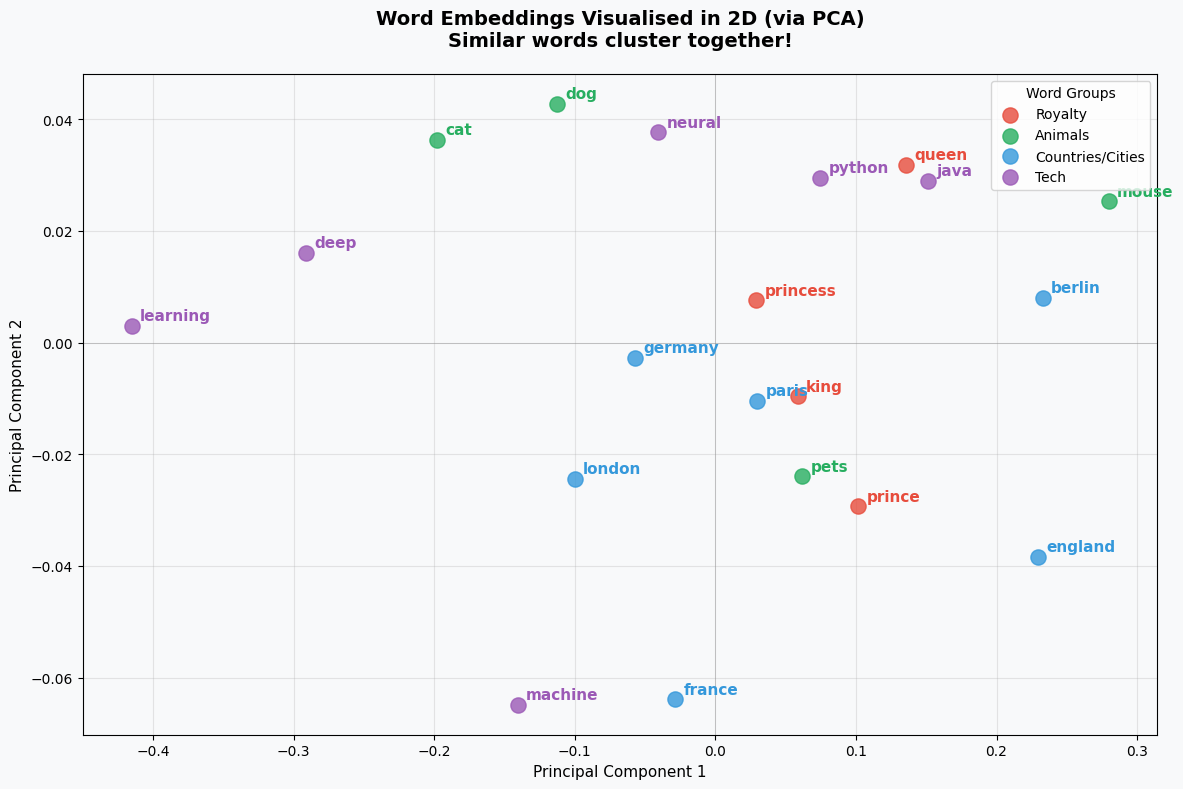

✅ Visualisation saved!
💡 Notice: words from the same group tend to cluster together!


In [42]:
# ── 8.6 Visualising Word Embeddings with PCA ──────────────────────────────
# 50-dimensional vectors are impossible to visualise directly
# PCA (Principal Component Analysis) compresses them to 2D for plotting

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Choose words to visualise — pick groups of related words
words_to_plot = {
    'Royalty': ['king', 'queen', 'prince', 'princess'],
    'Animals': ['cat', 'dog', 'mouse', 'pets'],
    'Countries/Cities': ['paris', 'london', 'france', 'germany', 'berlin', 'england'],
    'Tech': ['python', 'java', 'machine', 'learning', 'deep', 'neural'],
}

colors = {'Royalty': '#E74C3C', 'Animals': '#27AE60',
          'Countries/Cities': '#3498DB', 'Tech': '#9B59B6'}

# Get vectors for words that exist in our vocabulary
valid_words, valid_vectors, word_groups = [], [], []
for group, words in words_to_plot.items():
    for word in words:
        if word in model.wv.key_to_index:
            valid_words.append(word)
            valid_vectors.append(model.wv[word])
            word_groups.append(group)

# PCA: reduce from 50D → 2D
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(np.array(valid_vectors))

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

plotted_groups = set()
for i, (word, group) in enumerate(zip(valid_words, word_groups)):
    x, y = coords_2d[i]
    label = group if group not in plotted_groups else None
    ax.scatter(x, y, color=colors[group], s=120, alpha=0.8,
               label=label, zorder=3)
    ax.annotate(word, (x, y),
                textcoords='offset points', xytext=(6, 4),
                fontsize=11, fontweight='bold',
                color=colors[group])
    plotted_groups.add(group)

ax.set_title('Word Embeddings Visualised in 2D (via PCA)\n'
             'Similar words cluster together!',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Principal Component 1', fontsize=11)
ax.set_ylabel('Principal Component 2', fontsize=11)
ax.legend(loc='upper right', fontsize=10, title='Word Groups')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig('/content/word_embeddings_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisation saved!")
print("💡 Notice: words from the same group tend to cluster together!")

In [43]:
# ── 8.7 Loading Pre-Trained Word2Vec (Google News Vectors) ────────────────
# Our tiny model has 25 words.
# Google's Word2Vec was trained on 100 BILLION words from Google News
# → 3 million word vectors, each 300-dimensional
# → Much more powerful analogies and similarities

# ⚠️  The full model is 3.6GB — we'll load a smaller version for this session
print("Loading 'word2vec-google-news-300' (subset via gensim)...")
print("This may take 1-2 minutes on first run (downloads ~1.6 GB)")
print()

try:
    # Load the model (downloads on first run, cached after)
    wv = api.load('word2vec-google-news-300')
    print(f"✅ Loaded! Vocabulary: {len(wv.key_to_index):,} words, {wv.vector_size} dimensions")
    model_loaded = True
except Exception as e:
    print(f"⚠️  Could not load large model: {e}")
    print("   Using our small trained model instead.")
    wv = model.wv
    model_loaded = False

Loading 'word2vec-google-news-300' (subset via gensim)...
This may take 1-2 minutes on first run (downloads ~1.6 GB)

[==================================================] 100.0% 1662.8/1662.8MB downloaded
✅ Loaded! Vocabulary: 3,000,000 words, 300 dimensions


In [44]:
# ── 8.8 Exploring the Pre-Trained Model ───────────────────────────────────
# Let's test the famous king - man + woman = queen on the real model

if model_loaded:
    print("=" * 60)
    print("Analogies with Google News Word2Vec (3B word training corpus)")
    print("=" * 60)

    analogies_real = [
        (('king', 'woman'), ('man',),      'king - man + woman = ?'),
        (('Paris', 'Germany'), ('France',), 'Paris - France + Germany = ?'),
        (('Tokyo', 'China'), ('Japan',),    'Tokyo - Japan + China = ?'),
        (('swimming', 'ran'), ('swim',),    'swimming - swim + ran = ?'),
    ]

    for pos, neg, question in analogies_real:
        results = wv.most_similar(positive=list(pos), negative=list(neg), topn=3)
        print(f"\n  {question}")
        for word, score in results:
            print(f"    → '{word}' (similarity: {score:.4f})")

    print()
    print("=" * 60)
    print("Most similar words:")
    for word in ['doctor', 'computer', 'London']:
        print(f"\n  Most similar to '{word}':")
        for w, s in wv.most_similar(word, topn=5):
            print(f"    {w:<20} {s:.4f}")
else:
    print("Using small model. Results may be limited.")
    print("Try: wv.most_similar('cat', topn=5)")

Analogies with Google News Word2Vec (3B word training corpus)

  king - man + woman = ?
    → 'queen' (similarity: 0.7118)
    → 'monarch' (similarity: 0.6190)
    → 'princess' (similarity: 0.5902)

  Paris - France + Germany = ?
    → 'Berlin' (similarity: 0.7644)
    → 'Frankfurt' (similarity: 0.7330)
    → 'Dusseldorf' (similarity: 0.7009)

  Tokyo - Japan + China = ?
    → 'Beijing' (similarity: 0.8216)
    → 'Shanghai' (similarity: 0.7951)
    → 'Guangzhou' (similarity: 0.6530)

  swimming - swim + ran = ?
    → 'went' (similarity: 0.6099)
    → 'running' (similarity: 0.5654)
    → 'raced' (similarity: 0.5504)

Most similar words:

  Most similar to 'doctor':
    physician            0.7806
    doctors              0.7477
    gynecologist         0.6948
    surgeon              0.6793
    dentist              0.6785

  Most similar to 'computer':
    computers            0.7979
    laptop               0.6640
    laptop_computer      0.6549
    Computer             0.6473
    com_

In [45]:
# ── 8.9 Limitations of Word2Vec ────────────────────────────────────────────
# Word2Vec is powerful but has important limitations

print("⚠️  Limitations of Word2Vec:")
print()
print("1. ONE VECTOR PER WORD — ignores polysemy (multiple meanings)")
print("   'bank' always maps to the SAME vector, regardless of context")
print("   (financial bank vs river bank vs bank shot in billiards)")
print()

if model_loaded:
    try:
        bank_sim = wv.most_similar('bank', topn=8)
        print("   Words similar to 'bank' (mixes both meanings):")
        for w, s in bank_sim:
            print(f"     {w:<20} {s:.4f}")
    except:
        pass

print()
print("2. OUT-OF-VOCABULARY — words not in training data have no vector")
print("   'ChatGPT', 'iPhone16', 'COVID-19' are not in a 2013 model")
print()
print("3. STATIC — vectors are fixed after training")
print("   Cannot update when language changes (new slang, new words)")
print()
print("━" * 60)
print("🚀 BERT (2018) solved limitation #1 — it creates CONTEXTUAL embeddings")
print("   'bank' in 'river bank' gets a DIFFERENT vector than in 'central bank'")
print("   That's what makes modern LLMs so powerful!")
print("━" * 60)

⚠️  Limitations of Word2Vec:

1. ONE VECTOR PER WORD — ignores polysemy (multiple meanings)
   'bank' always maps to the SAME vector, regardless of context
   (financial bank vs river bank vs bank shot in billiards)

   Words similar to 'bank' (mixes both meanings):
     banks                0.7441
     banking              0.6902
     Bank                 0.6699
     lender               0.6342
     banker               0.6093
     depositors           0.6032
     mortgage_lender      0.5798
     depositor            0.5716

2. OUT-OF-VOCABULARY — words not in training data have no vector
   'ChatGPT', 'iPhone16', 'COVID-19' are not in a 2013 model

3. STATIC — vectors are fixed after training
   Cannot update when language changes (new slang, new words)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚀 BERT (2018) solved limitation #1 — it creates CONTEXTUAL embeddings
   'bank' in 'river bank' gets a DIFFERENT vector than in 'central bank'
   That's what makes modern L

In [46]:
# ── 8.10 Document Embeddings — From Words to Sentences ────────────────────
# Word2Vec gives us word vectors. How do we get a vector for a SENTENCE?
# Simplest approach: AVERAGE the word vectors

def sentence_to_vector(sentence: str, word_vectors) -> np.ndarray:
    """
    Convert a sentence to a vector by averaging its word vectors.
    Words not in vocabulary are skipped.
    """
    tokens = sentence.lower().split()
    vectors = []
    for token in tokens:
        try:
            vectors.append(word_vectors[token])
        except KeyError:
            pass  # skip OOV words

    if vectors:
        return np.mean(vectors, axis=0)   # Average all word vectors
    else:
        return np.zeros(word_vectors.vector_size)


# Test sentence similarity using averaged embeddings
sentences_test = [
    "the cat sat on the mat",
    "the dog sat on the rug",       # Similar to S1
    "machine learning is great",
    "artificial intelligence is amazing",  # Similar to S3
    "the king rules the kingdom",
]

# Use our small model (our trained wv)
vecs = [sentence_to_vector(s, model.wv) for s in sentences_test]

# Compute cosine similarity between all pairs
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(vecs)

df_sim = pd.DataFrame(
    sim_matrix.round(3),
    index=[f'S{i+1}' for i in range(len(sentences_test))],
    columns=[f'S{i+1}' for i in range(len(sentences_test))]
)

print("Sentence Similarity Matrix (averaged Word2Vec):")
print(df_sim)
print()
print("Sentences:")
for i, s in enumerate(sentences_test, 1):
    print(f"  S{i}: {s}")
print()
print("💡 S1 & S2 (animal sentences) should be more similar than S1 & S4 (ML sentence)")

Sentence Similarity Matrix (averaged Word2Vec):
       S1     S2     S3     S4     S5
S1  1.000  0.999  0.995  0.995  0.998
S2  0.999  1.000  0.995  0.995  0.998
S3  0.995  0.995  1.000  0.998  0.995
S4  0.995  0.995  0.998  1.000  0.995
S5  0.998  0.998  0.995  0.995  1.000

Sentences:
  S1: the cat sat on the mat
  S2: the dog sat on the rug
  S3: machine learning is great
  S4: artificial intelligence is amazing
  S5: the king rules the kingdom

💡 S1 & S2 (animal sentences) should be more similar than S1 & S4 (ML sentence)


---
# Putting It All Together: The Full NLP Pipeline

Let's build a complete end-to-end pipeline from raw text to vector representation.

In [47]:
# ── Complete NLP Preprocessing Pipeline ───────────────────────────────────

# Sample dataset of movie reviews
reviews = [
    ("positive", "This movie was absolutely fantastic! Great acting and amazing story."),
    ("positive", "I loved every minute. The characters were incredible and so relatable."),
    ("positive", "One of the best films I've ever seen. Outstanding cinematography!"),
    ("negative", "Terrible movie. I wasted 2 hours of my life watching this garbage."),
    ("negative", "Worst film ever made. The acting was horrible and the plot made no sense."),
    ("negative", "Boring, predictable, and completely unenjoyable. Do not watch."),
    ("neutral",  "The movie was okay. Some parts were good but others were slow."),
    ("neutral",  "Not great, not terrible. It was a decent way to pass the time."),
]

labels = [r[0] for r in reviews]
texts  = [r[1] for r in reviews]

# ── Stage 1: Clean text ──
print("STAGE 1: Text Cleaning (regex)")
cleaned = [clean_text(t) for t in texts]
for orig, clean in zip(texts[:3], cleaned[:3]):
    print(f"  Before: {orig}")
    print(f"  After : {clean}")
    print()

# ── Stage 2: Preprocess (tokenise + stopwords + lemmatise) ──
print("STAGE 2: Tokenise + Stopwords + Lemmatise")
preprocessed = [' '.join(preprocess(t)) for t in texts]  # Join back to string for vectoriser
for p in preprocessed[:3]:
    print(f"  {p}")
print()

# ── Stage 3: TF-IDF Vectorisation ──
print("STAGE 3: TF-IDF Vectorisation")
tfidf_vec = TfidfVectorizer(max_features=20)
X = tfidf_vec.fit_transform(preprocessed)
print(f"  Feature matrix shape: {X.shape}  ({X.shape[0]} reviews, {X.shape[1]} features)")
print(f"  Features: {list(tfidf_vec.get_feature_names_out())}")
print()

# ── Stage 4: Simple Classification ──
print("STAGE 4: Logistic Regression Classifier")
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000, random_state=42)
scores = cross_val_score(clf, X, labels, cv=3, scoring='accuracy')
print(f"  Cross-validation accuracy: {scores.mean():.2%} (+/- {scores.std():.2%})")
print()
print("  (Note: with only 8 samples, results are just illustrative)")
print()

# Train and test on a new review
clf.fit(X, labels)
new_review = "This was an excellent film with brilliant performances!"
new_vec = tfidf_vec.transform([' '.join(preprocess(new_review))])
prediction = clf.predict(new_vec)[0]
print(f"  New review: '{new_review}'")
print(f"  Predicted sentiment: {prediction.upper()} ✅")

STAGE 1: Text Cleaning (regex)
  Before: This movie was absolutely fantastic! Great acting and amazing story.
  After : this movie was absolutely fantastic great acting and amazing story

  Before: I loved every minute. The characters were incredible and so relatable.
  After : i loved every minute the characters were incredible and so relatable

  Before: One of the best films I've ever seen. Outstanding cinematography!
  After : one of the best films ive ever seen outstanding cinematography

STAGE 2: Tokenise + Stopwords + Lemmatise
  movie absolutely fantastic great acting amazing story
  loved every minute character incredible relatable
  one best film ive ever seen outstanding cinematography

STAGE 3: TF-IDF Vectorisation
  Feature matrix shape: (8, 20)  (8 reviews, 20 features)
  Features: ['absolutely', 'acting', 'amazing', 'boring', 'character', 'cinematography', 'completely', 'decent', 'ever', 'every', 'fantastic', 'film', 'garbage', 'good', 'great', 'horrible', 'incredible', 

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


---
# 🏁 Summary & Key Takeaways

## What We Covered Today

| Concept | Key Library | What It Does |
|---------|------------|-------------|
| **Text Strings** | Python built-in | `.lower()`, `.split()`, `.replace()` |
| **Regex** | `re` | Pattern matching — clean, extract, split |
| **Tokenisation** | `nltk`, `spacy` | Split text into words or sentences |
| **Stopwords** | `nltk` | Remove common, uninformative words |
| **Stemming** | `nltk.PorterStemmer` | Crude suffix stripping (fast) |
| **Lemmatisation** | `nltk.WordNetLemmatizer`, `spacy` | Dictionary-accurate base forms |
| **Bag of Words** | `sklearn.CountVectorizer` | Word count vectors |
| **N-Grams** | `sklearn.CountVectorizer(ngram_range)` | Capture word pairs/triples |
| **TF-IDF** | `sklearn.TfidfVectorizer` | Word importance-weighted vectors |
| **Word2Vec** | `gensim.Word2Vec` | Dense semantic word vectors |

---

## The Evolution of Text Representations

```
1960s   Rule-Based       Hand-crafted grammars and patterns
   ↓
1990s   Bag of Words     Count-based, sparse, ignores order
   ↓
2000s   TF-IDF           Weighted counts, still sparse
   ↓
2013    Word2Vec         Dense vectors, captures semantics
   ↓
2014    GloVe            Global co-occurrence statistics
   ↓
2018    BERT / ELMo      CONTEXTUAL embeddings — 'bank' in
                         'river bank' ≠ 'bank' in 'central bank'
   ↓
2020+   GPT-3/4, LLaMA   Trillion-parameter, few-shot capable
```

---

In [48]:
# ═══════════════════════════════════════════════════════════════
# ✏️  Final Challenge: Build Your Own NLP Pipeline
# ═══════════════════════════════════════════════════════════════
#
# Given these movie review sentences, do the following:
#   1. Clean the text (remove URLs, punctuation, lowercase)
#   2. Tokenise and remove stopwords
#   3. Create a TF-IDF matrix
#   4. Find the most important word in each review (highest TF-IDF score)
#   5. BONUS: Use Word2Vec to find the most similar word to 'excellent'
#
# ═══════════════════════════════════════════════════════════════

challenge_reviews = [
    "An absolutely BRILLIANT film! Visit https://example.com for tickets.",
    "The special effects were stunning but the story was confusing.",
    "Disappointing. The trailer was better than the actual movie itself.",
    "Oscar-worthy performances from the entire cast. A must-see!",
]

print("=" * 60)
print("YOUR CHALLENGE")
print("=" * 60)
print()
print("Complete the pipeline below:")

# TODO: Step 1 — Clean the text
# cleaned_reviews = [clean_text(r) for r in challenge_reviews]

# TODO: Step 2 — Preprocess (tokenise + stopwords + lemmatise)
# preprocessed_reviews = [' '.join(preprocess(r)) for r in challenge_reviews]

# TODO: Step 3 — TF-IDF
# tfidf = TfidfVectorizer()
# matrix = tfidf.fit_transform(preprocessed_reviews)

# TODO: Step 4 — Find top word per review
# ...

# ─── SOLUTION (uncomment to reveal) ───
print("\n--- Solution ---")
step1 = [clean_text(r) for r in challenge_reviews]
step2 = [' '.join(preprocess(r)) for r in challenge_reviews]
tv = TfidfVectorizer()
mat = tv.fit_transform(step2)
feat = tv.get_feature_names_out()

print("Most important word per review:")
for i, review in enumerate(challenge_reviews):
    row = mat[i].toarray()[0]
    top_idx = row.argmax()
    print(f"  Review {i+1}: '{feat[top_idx]}' (score={row[top_idx]:.3f})")
    print(f"  → {review[:60]}...")
    print()

YOUR CHALLENGE

Complete the pipeline below:

--- Solution ---
Most important word per review:
  Review 1: 'absolutely' (score=0.447)
  → An absolutely BRILLIANT film! Visit https://example.com for ...

  Review 2: 'confusing' (score=0.447)
  → The special effects were stunning but the story was confusin...

  Review 3: 'actual' (score=0.447)
  → Disappointing. The trailer was better than the actual movie ...

  Review 4: 'cast' (score=0.447)
  → Oscar-worthy performances from the entire cast. A must-see!...



---

# 🎓 Well done for completing the session!

You have successfully gone from **raw text** all the way to **word embeddings** — the foundation of all modern NLP.

```
Raw Text
  ↓ regex cleaning
Clean Text
  ↓ tokenisation
Tokens
  ↓ stopword removal + lemmatisation
Normalised Tokens
  ↓ CountVectorizer / TfidfVectorizer
Sparse Vectors (BoW / TF-IDF)
  ↓ Word2Vec
Dense Semantic Vectors (Embeddings)
  ↓ BERT / GPT (next sessions!)
Contextual Embeddings
```

> **Remember**: The best NLP practitioners always start simple.  
> A TF-IDF + Logistic Regression baseline often gets you 80-90% of the way.
> Only reach for transformers when you need that extra push.

---
*Gudsky Research Foundation — Research Intake Programme 2026 — Day 10*